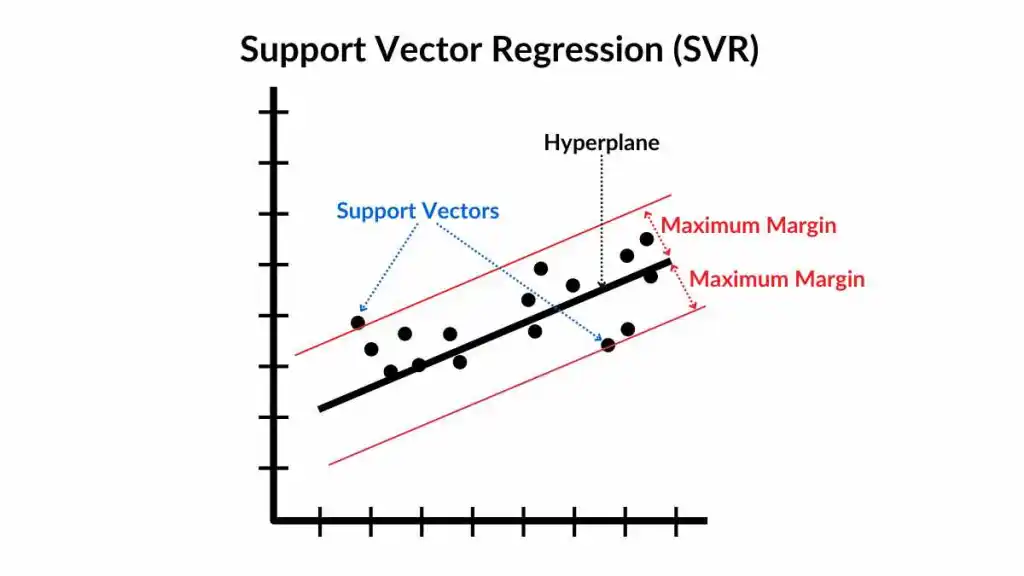

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error
import pandas as pd
import numpy as np

In [10]:
dataset = pd.read_csv('houses.csv')


X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

print(X.shape)
print(y.shape)

dataset.head(5)


(1000, 17)
(1000,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


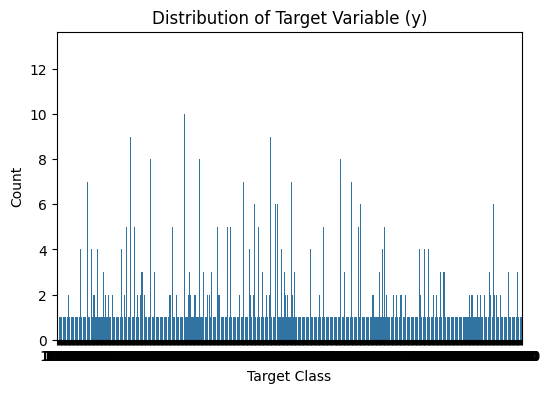

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

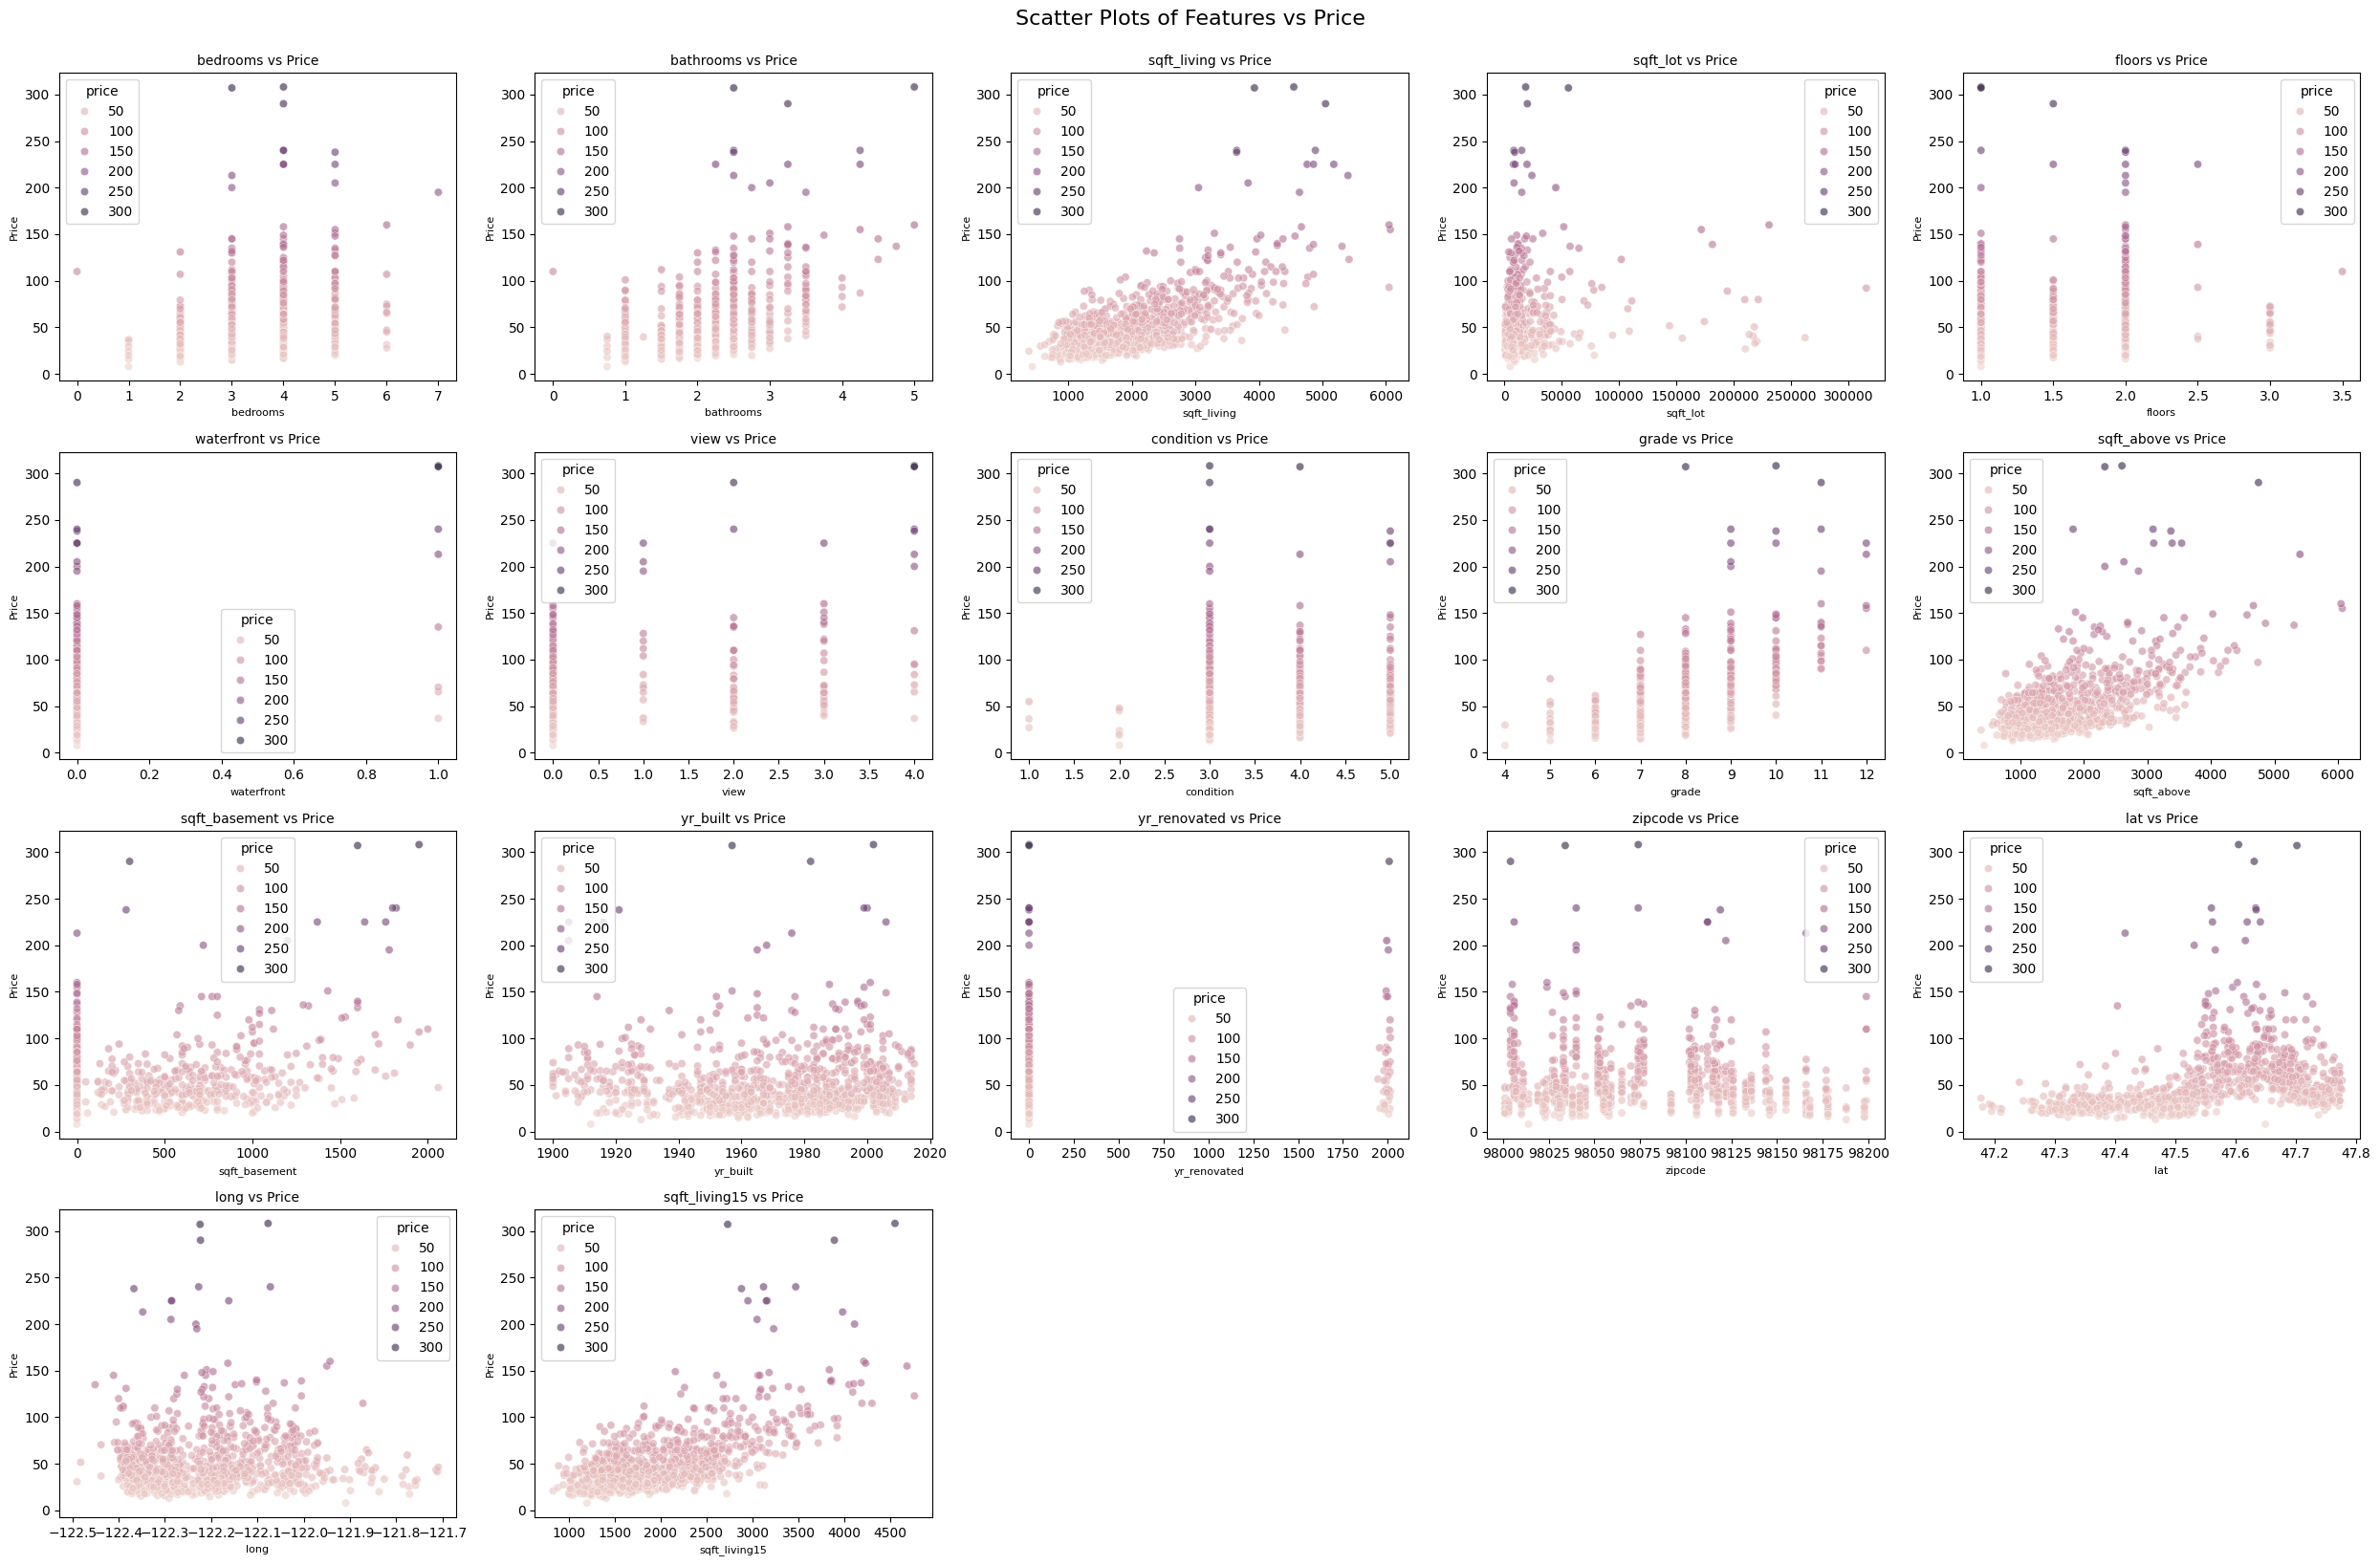

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dataset is already defined from previous cells and contains 'price' column

# Get feature names from the 'dataset' DataFrame, excluding the 'price' column
feature_names = [col for col in dataset.columns if col != 'price']
n_features = len(feature_names)

# Determine grid size for subplots (e.g., 5 columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    sns.scatterplot(x=dataset[feature_name], y=dataset['price'], hue=dataset['price'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature_name} vs Price', fontsize=10)
    axes[i].set_xlabel(feature_name, fontsize=8)
    axes[i].set_ylabel('Price', fontsize=8)
    # The following lines for y-ticks are commented out because 'price' is a continuous variable, not binary
    # axes[i].set_yticks([0, 1]) # Set y-ticks for binary target
    # axes[i].set_yticklabels(['Benign (0)', 'Malignant (1)']) # Label y-ticks

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Features vs Price', y=1.02, fontsize=16)
plt.show()

In [16]:
print(f"Data types of X:\n{X.dtypes}")
print(f"Are all columns in X numerical? {all(np.issubdtype(dtype, np.number) for dtype in X.dtypes)}")
print(f"Data type of y: {y.dtype}")
print(f"Is y fully numerical? {np.issubdtype(y.dtype, np.number)}")

Data types of X:
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
yr_renovated     float64
zipcode          float64
lat              float64
long             float64
sqft_living15    float64
dtype: object
Are all columns in X numerical? True
Data type of y: float64
Is y fully numerical? True


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=44,
                                                    shuffle=True)

In [18]:
print("Null values in X:", np.isnan(X).sum())
print("Null values in y:", np.isnan(y).sum())

Null values in X: bedrooms         1
bathrooms        1
sqft_living      1
sqft_lot         1
floors           1
waterfront       1
view             1
condition        1
grade            1
sqft_above       1
sqft_basement    1
yr_built         1
yr_renovated     1
zipcode          1
lat              1
long             1
sqft_living15    1
dtype: int64
Null values in y: 1


In [21]:
# Impute missing values in X_train and X_test with the median from X_train
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Impute missing values in y_train and y_test with the median from y_train
y_train_median = y_train.median()
y_train.fillna(y_train_median, inplace=True)
y_test.fillna(y_train_median, inplace=True)

print("Null values in X_train after imputation:", X_train.isnull().sum().sum())
print("Null values in y_train after imputation:", y_train.isnull().sum())
print("Null values in X_test after imputation:", X_test.isnull().sum().sum())
print("Null values in y_test after imputation:", y_test.isnull().sum())

Null values in X_train after imputation: 0
Null values in y_train after imputation: 0
Null values in X_test after imputation: 0
Null values in y_test after imputation: 0


/tmp/ipykernel_4561/168246013.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
/tmp/ipykernel_4561/168246013.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the training features (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test features (X_test)
X_test_scaled = scaler.transform(X_test)


In [39]:
SVRModel = SVR(C=1.0, epsilon=0.1, kernel = 'rbf')
SVRModel.fit(X_train_scaled, y_train)

SVR()

In [40]:
print(SVRModel.score(X_train_scaled, y_train))
print(SVRModel.score(X_test_scaled, y_test))


0.3315333902095826
0.31134651604063723


In [41]:
y_pred = SVRModel.predict(X_test_scaled)

In [45]:
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Median Absolute Error (MedAE): {median_absolute_error(y_test, y_pred):.2f}")

Mean Squared Error (MSE): 838.68
Mean Absolute Error (MAE): 14.03
Median Absolute Error (MedAE): 7.16
